# Module 1

## Task 1: Load all CSV files into PySpark DataFrames

In [33]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, regexp_replace, round
import matplotlib.pyplot as plt

In [10]:
spark = SparkSession.builder \
    .appName("COVID19 Analytics Pipeline") \
    .getOrCreate()

In [11]:
full_grouped_path = "data/full_grouped.csv"
clean_complete_path = "data/covid_19_clean_complete.csv"
country_latest_path = "data/country_wise_latest.csv"
day_wise_path = "data/day_wise.csv"
usa_county_path = "data/usa_county_wise.csv"
worldometer_path = "data/worldometer_data.csv"

In [12]:
full_grouped_df = spark.read.csv(
    full_grouped_path,
    header=True,
    inferSchema=True
)

clean_complete_df = spark.read.csv(
    clean_complete_path,
    header=True,
    inferSchema=True
)

country_latest_df = spark.read.csv(
    country_latest_path,
    header=True,
    inferSchema=True
)

day_wise_df = spark.read.csv(
    day_wise_path,
    header=True,
    inferSchema=True
)

usa_county_df = spark.read.csv(
    usa_county_path,
    header=True,
    inferSchema=True
)

worldometer_df = spark.read.csv(
    worldometer_path,
    header=True,
    inferSchema=True
)

In [13]:
datasets = {
    "full_grouped": full_grouped_df,
    "covid_19_clean_complete": clean_complete_df,
    "country_wise_latest": country_latest_df,
    "day_wise": day_wise_df,
    "usa_county_wise": usa_county_df,
    "worldometer_data": worldometer_df
}

In [14]:
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(f"Dataset: {name}")
    print("=" * 60)

    print("\nSchema:")
    df.printSchema()

    print(f"\nTotal Rows: {df.count()}")


Dataset: full_grouped

Schema:
root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)


Total Rows: 35156

Dataset: covid_19_clean_complete

Schema:
root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)


Total Rows: 49068

Dataset: country_wise_latest

Schema:
root
 |-- Country/Re

# Module 2

## Task 2: Handle Missing Province/State Values

In [15]:
null_province_df = clean_complete_df.filter(
    col("Province/State").isNull()
)

print("Rows with NULL Province/State:")
null_province_df.show(10, truncate=False)

Rows with NULL Province/State:
+--------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|Province/State|Country/Region     |Lat     |Long     |Date      |Confirmed|Deaths|Recovered|Active|WHO Region           |
+--------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|NULL          |Afghanistan        |33.93911|67.709953|2020-01-22|0        |0     |0        |0     |Eastern Mediterranean|
|NULL          |Albania            |41.1533 |20.1683  |2020-01-22|0        |0     |0        |0     |Europe               |
|NULL          |Algeria            |28.0339 |1.6596   |2020-01-22|0        |0     |0        |0     |Africa               |
|NULL          |Andorra            |42.5063 |1.5218   |2020-01-22|0        |0     |0        |0     |Europe               |
|NULL          |Angola             |-11.2027|17.8739  |2020-01-22|0        |0     |0        |0     |Africa  

In [16]:
null_count_report = null_province_df.groupBy("Country/Region") \
    .agg(
        count("*").alias("null_province_count")
    ) \
    .orderBy(col("null_province_count").desc())

print("Country-wise NULL Province/State Count:")
null_count_report.show(truncate=False)

Country-wise NULL Province/State Count:
+--------------+-------------------+
|Country/Region|null_province_count|
+--------------+-------------------+
|Chad          |188                |
|Paraguay      |188                |
|Russia        |188                |
|Yemen         |188                |
|Senegal       |188                |
|Cabo Verde    |188                |
|Sweden        |188                |
|Guyana        |188                |
|Eritrea       |188                |
|Philippines   |188                |
|Burma         |188                |
|Djibouti      |188                |
|Malaysia      |188                |
|Singapore     |188                |
|Fiji          |188                |
|Turkey        |188                |
|Malawi        |188                |
|Western Sahara|188                |
|Iraq          |188                |
|Germany       |188                |
+--------------+-------------------+
only showing top 20 rows


In [17]:
clean_complete_df = clean_complete_df.fillna({
    "Province/State": "Unknown"
})

In [18]:
remaining_nulls = clean_complete_df.filter(
    col("Province/State").isNull()
).count()

print(f"Remaining NULL Province/State rows: {remaining_nulls}")

Remaining NULL Province/State rows: 0


In [19]:
clean_complete_df.show(10, truncate=False)

+----------------------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|Province/State              |Country/Region     |Lat     |Long     |Date      |Confirmed|Deaths|Recovered|Active|WHO Region           |
+----------------------------+-------------------+--------+---------+----------+---------+------+---------+------+---------------------+
|Unknown                     |Afghanistan        |33.93911|67.709953|2020-01-22|0        |0     |0        |0     |Eastern Mediterranean|
|Unknown                     |Albania            |41.1533 |20.1683  |2020-01-22|0        |0     |0        |0     |Europe               |
|Unknown                     |Algeria            |28.0339 |1.6596   |2020-01-22|0        |0     |0        |0     |Africa               |
|Unknown                     |Andorra            |42.5063 |1.5218   |2020-01-22|0        |0     |0        |0     |Europe               |
|Unknown                     |Angola     

## Task 3: Standardize Country Names

In [21]:
def standardize_country_names(df, column_name):

    return df.withColumn(
        column_name,

        when(col(column_name) == "US", "USA")
        .when(col(column_name) == "Korea, South", "South Korea")
        .when(col(column_name) == "UK", "United Kingdom")
        .when(col(column_name) == "UAE", "United Arab Emirates")
        .otherwise(col(column_name))
    )


In [22]:
full_grouped_df = standardize_country_names(
    full_grouped_df,
    "Country/Region"
)

country_latest_df = standardize_country_names(
    country_latest_df,
    "Country/Region"
)

worldometer_df = standardize_country_names(
    worldometer_df,
    "Country/Region"
)

In [23]:
full_grouped_df = full_grouped_df.withColumn(
    "Country/Region",
    regexp_replace(col("Country/Region"), r"^\s+|\s+$", "")
)

country_latest_df = country_latest_df.withColumn(
    "Country/Region",
    regexp_replace(col("Country/Region"), r"^\s+|\s+$", "")
)

worldometer_df = worldometer_df.withColumn(
    "Country/Region",
    regexp_replace(col("Country/Region"), r"^\s+|\s+$", "")
)

In [24]:
print("Distinct Countries - full_grouped")
full_grouped_df.select("Country/Region").distinct().show(20, truncate=False)

print("Distinct Countries - country_wise_latest")
country_latest_df.select("Country/Region").distinct().show(20, truncate=False)

print("Distinct Countries - worldometer_data")
worldometer_df.select("Country/Region").distinct().show(20, truncate=False)

Distinct Countries - full_grouped
+--------------+
|Country/Region|
+--------------+
|Chad          |
|Paraguay      |
|Russia        |
|Yemen         |
|Senegal       |
|Cabo Verde    |
|Sweden        |
|Guyana        |
|Burma         |
|Eritrea       |
|Philippines   |
|Djibouti      |
|Malaysia      |
|Singapore     |
|Fiji          |
|Turkey        |
|Malawi        |
|Western Sahara|
|Iraq          |
|Germany       |
+--------------+
only showing top 20 rows
Distinct Countries - country_wise_latest
+--------------+
|Country/Region|
+--------------+
|Chad          |
|Paraguay      |
|Russia        |
|Yemen         |
|Senegal       |
|Cabo Verde    |
|Sweden        |
|Guyana        |
|Burma         |
|Eritrea       |
|Philippines   |
|Djibouti      |
|Malaysia      |
|Singapore     |
|Fiji          |
|Turkey        |
|Malawi        |
|Western Sahara|
|Iraq          |
|Germany       |
+--------------+
only showing top 20 rows
Distinct Countries - worldometer_data
+----------------+
|C

## Task 4: Remove Duplicate Daily Records

In [25]:
duplicate_full_grouped = full_grouped_df.groupBy(
    "Country/Region",
    "Date"
).count().filter("count > 1")

print("Duplicate Records in full_grouped:")
duplicate_full_grouped.show(truncate=False)

Duplicate Records in full_grouped:
+--------------+----+-----+
|Country/Region|Date|count|
+--------------+----+-----+
+--------------+----+-----+



In [26]:
duplicate_clean_complete = clean_complete_df.groupBy(
    "Country/Region",
    "Date"
).count().filter("count > 1")

print("Duplicate Records in clean_complete:")
duplicate_clean_complete.show(truncate=False)

Duplicate Records in clean_complete:
+--------------+----------+-----+
|Country/Region|Date      |count|
+--------------+----------+-----+
|China         |2020-05-01|33   |
|Netherlands   |2020-06-08|4    |
|Australia     |2020-06-10|8    |
|Denmark       |2020-06-21|2    |
|United Kingdom|2020-07-03|11   |
|Netherlands   |2020-04-20|4    |
|Australia     |2020-05-10|8    |
|Australia     |2020-07-16|8    |
|United Kingdom|2020-05-03|11   |
|Australia     |2020-05-14|8    |
|Australia     |2020-05-29|8    |
|China         |2020-06-06|33   |
|Netherlands   |2020-07-12|4    |
|France        |2020-07-13|11   |
|Canada        |2020-07-25|12   |
|Denmark       |2020-07-25|2    |
|China         |2020-01-28|33   |
|Denmark       |2020-02-25|2    |
|Australia     |2020-05-01|8    |
|France        |2020-05-27|11   |
+--------------+----------+-----+
only showing top 20 rows


In [27]:
clean_complete_df = clean_complete_df.dropDuplicates([
    "Country/Region",
    "Date"
])

In [28]:
print("Row Count After Removing Duplicates")

print(f"full_grouped_df: {full_grouped_df.count()}")
print(f"clean_complete_df: {clean_complete_df.count()}")

Row Count After Removing Duplicates
full_grouped_df: 35156
clean_complete_df: 35156


# Module 3

## Task 5: Top 10 Countries by Total Confirmed Cases

In [29]:
top_confirmed_df = country_latest_df.select(
    "Country/Region",
    "Confirmed"
)

top_10_confirmed = top_confirmed_df.orderBy(
    col("Confirmed").desc()
).limit(10)

top_10_confirmed.show(truncate=False)

+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
|USA           |4290259  |
|Brazil        |2442375  |
|India         |1480073  |
|Russia        |816680   |
|South Africa  |452529   |
|Mexico        |395489   |
|Peru          |389717   |
|Chile         |347923   |
|United Kingdom|301708   |
|Iran          |293606   |
+--------------+---------+



In [30]:
top_10_pd = top_10_confirmed.toPandas()

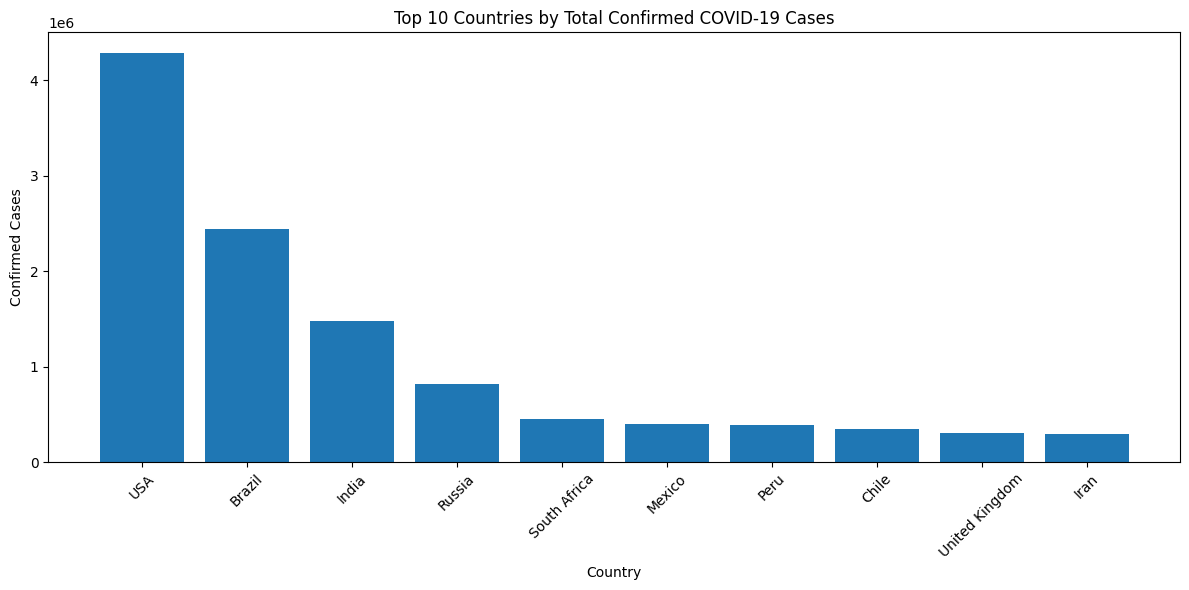

In [32]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_10_pd["Country/Region"],
    top_10_pd["Confirmed"]
)

plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.title("Top 10 Countries by Total Confirmed COVID-19 Cases")

plt.tight_layout()
plt.show()

## Task 6: Top 10 Countries by Death Rate

In [34]:
death_rate_df = country_latest_df.withColumn(
    "Death_Rate",
    round(
        (col("Deaths") / col("Confirmed")) * 100,
        2
    )
)

In [35]:
top_10_death_rate = death_rate_df.select(
    "Country/Region",
    "Deaths",
    "Confirmed",
    "Death_Rate"
).filter(
    col("Confirmed") > 0
).orderBy(
    col("Death_Rate").desc()
).limit(10)

top_10_death_rate.show(truncate=False)

+--------------+------+---------+----------+
|Country/Region|Deaths|Confirmed|Death_Rate|
+--------------+------+---------+----------+
|Yemen         |483   |1691     |28.56     |
|United Kingdom|45844 |301708   |15.19     |
|Belgium       |9822  |66428    |14.79     |
|Italy         |35112 |246286   |14.26     |
|France        |30212 |220352   |13.71     |
|Hungary       |596   |4448     |13.4      |
|Netherlands   |6160  |53413    |11.53     |
|Mexico        |44022 |395489   |11.13     |
|Spain         |28432 |272421   |10.44     |
|Western Sahara|1     |10       |10.0      |
+--------------+------+---------+----------+



In [37]:
top_10_death_rate_pd = top_10_death_rate.toPandas()

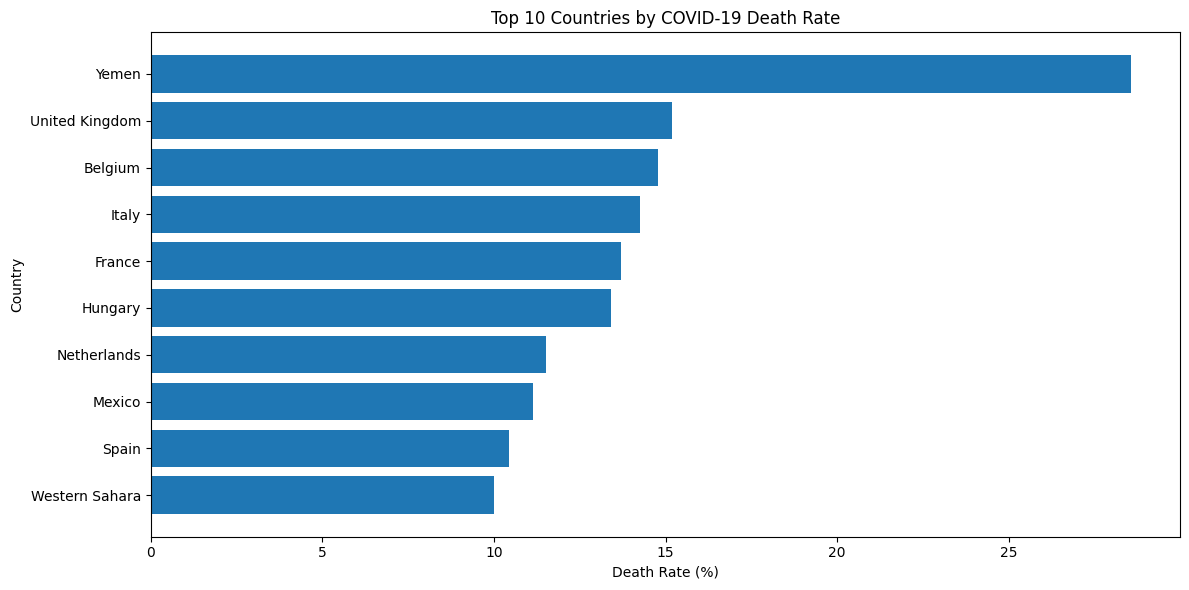

In [38]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_10_death_rate_pd["Country/Region"],
    top_10_death_rate_pd["Death_Rate"]
)

plt.xlabel("Death Rate (%)")
plt.ylabel("Country")
plt.title("Top 10 Countries by COVID-19 Death Rate")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()